In [1]:
import pandas as pd

In [2]:
mutations_df = pd.read_csv("../data/data.csv")
mutations_df.Brightness = mutations_df.Brightness.astype('float32')

In [6]:
mutations_df

,Unnamed: 0,aaMutations,GFP type,Brightness,seq
0,0,WT,avGFP,3.719212,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
1,1,A109D,avGFP,1.301030,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
2,2,A109D:N145D:I187V:M232T:L235P,avGFP,1.301031,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
3,3,A109D:Y142N:H147L:E221G,avGFP,1.301189,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
4,4,A109G,avGFP,3.708478,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...
...,...,...,...,...,...
141567,141567,T128A:V150A:S158P,ppluGFP,4.035788,MPAMKIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALT...
141568,141568,E122K:S171P:V196A,ppluGFP,4.096312,MPAMKIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALT...
141569,141569,G22D,ppluGFP,4.068633,MPAMKIECRITGTLNGVEFELVDGGEGTPEQGRMTNKMKSTKGALT...
141570,141570,G107C:S171T:T203A,ppluGFP,3.939097,MPAMKIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALT...


<Axes: >

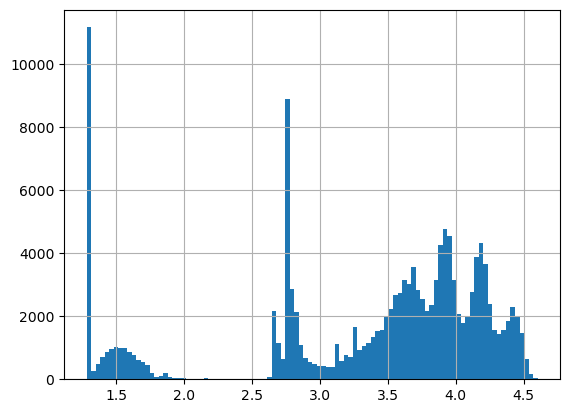

In [5]:
mutations_df.Brightness.hist(bins=100)

In [12]:
p1 = 2.5
p2 = 3

In [16]:
df = mutations_df.query("Brightness >= @p2")

In [19]:
df

,Unnamed: 0,aaMutations,GFP type,Brightness,seq,brightness_group
0,0,WT,avGFP,3.719212,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,Q2
4,4,A109G,avGFP,3.708478,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,Q2
5,5,A109G:K139M:R167C:L235P,avGFP,3.582764,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,Q1
7,7,A109G:K157R,avGFP,3.659013,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,Q2
8,8,A109G:K157R:I160V:I187V:T224S,avGFP,3.573855,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,Q1
...,...,...,...,...,...,...
141567,141567,T128A:V150A:S158P,ppluGFP,4.035788,MPAMKIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALT...,Q3
141568,141568,E122K:S171P:V196A,ppluGFP,4.096312,MPAMKIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALT...,Q3
141569,141569,G22D,ppluGFP,4.068633,MPAMKIECRITGTLNGVEFELVDGGEGTPEQGRMTNKMKSTKGALT...,Q3
141570,141570,G107C:S171T:T203A,ppluGFP,3.939097,MPAMKIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALT...,Q3


In [20]:
from sklearn.model_selection import train_test_split

df['brightness_group'] = pd.qcut(
    df['Brightness'], 
    q=4,  # 4 группы: очень тусклые, тусклые, яркие, очень яркие
    labels=['Q1', 'Q2', 'Q3', 'Q4'],
    duplicates='drop'  # если много одинаковых значений
)

# 2. Первый сплит (train+val vs test) со стратификацией
X_temp, X_test, y_temp, y_test = train_test_split(
    df['seq'],
    df['Brightness'],
    test_size=0.15,
    stratify=df['brightness_group'],  # <-- СТРАТИФИКАЦИЯ!
    random_state=42
)

# 3. Второй сплит (train vs val) - тоже со стратификацией
# Нужно создать группы для временной выборки
temp_groups = df.loc[X_temp.index, 'brightness_group']

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,  
    stratify=temp_groups,  
    random_state=42
)

/tmp/d_ryabov.4971/ipykernel_171245/15863782.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['brightness_group'] = pd.qcut(


In [24]:
pd.concat([X_train, y_train], axis=1).to_csv('../data/top_brightness_df/train.csv')
pd.concat([X_val, y_val], axis=1).to_csv('../data/top_brightness_df/val.csv')
pd.concat([X_test, y_test], axis=1).to_csv('../data/top_brightness_df/test.csv')